# Visualising JPTs

This tutorial walks through all built-in visualisation options in `pyjpt`:

1. **Tree structure** — the full decision tree rendered as an SVG with per-leaf distribution plots
2. **Individual distributions** — CDF curves for numeric variables, bar charts for symbolic variables
3. **Posterior distributions** — the result of conditioning on evidence, visualised with both backends
4. **Plotly interactive plots** — the same API with interactive zoom, hover, and HTML export

Both the **Matplotlib** (static PNG/SVG) and **Plotly** (interactive HTML + static via kaleido) engines are covered.
Install them with:
```bash
pip install pyjpt[matplotlib]
pip install pyjpt[plotly]   # also installs kaleido for static export
```

## Setup

Fit a JPT on the Iris dataset — we reuse this model throughout the tutorial.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import plotly.io as pio
pio.renderers.default = "png"

import pandas as pd
import sklearn.datasets
from jpt.variables import infer_from_dataframe
from jpt.trees import JPT

iris = sklearn.datasets.load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = [iris.target_names[t] for t in iris.target]

variables = infer_from_dataframe(df)
varnames = {v.name: v for v in variables}
model = JPT(variables, min_samples_leaf=0.1)
model.fit(df)
model

<JPT #innernodes = 6, #leaves = 7 (13 total)>

## Tree Structure

`JPT.plot()` generates a Graphviz SVG of the full decision tree.  Each internal node shows the split variable and threshold; each leaf contains a mini-plot of every variable's marginal distribution in that region.

Pass `engine='matplotlib'` or `engine='plotly'` to control how the leaf mini-plots are rendered.  The method returns the path to the generated SVG file.

In [ ]:
import tempfile
from IPython.display import SVG, display

tmpdir = tempfile.mkdtemp()

svg_path = model.plot(
    title='Iris JPT',
    filename='iris_tree',
    directory=tmpdir,
    engine='matplotlib',
    view=False,
)
display(SVG(svg_path))

### Restricting which variables appear in leaves

Pass `plotvars` to show only a subset of variables inside each leaf — useful for large models with many variables.

In [ ]:
svg_path2 = model.plot(
    title='Iris — petal variables',
    filename='iris_petals',
    directory=tmpdir,
    engine='matplotlib',
    plotvars=[
        varnames['petal length (cm)'],
        varnames['petal width (cm)'],
        varnames['species'],
    ],
    view=False,
)
display(SVG(svg_path2))

## Plotting Individual Distributions

Every distribution object exposes a `.plot()` method.  Call it directly on a distribution retrieved from a leaf or from a posterior query.

### Numeric distribution — CDF

Numeric variables are represented as piecewise-linear CDFs.  The Matplotlib engine returns a `Figure` you can display inline.

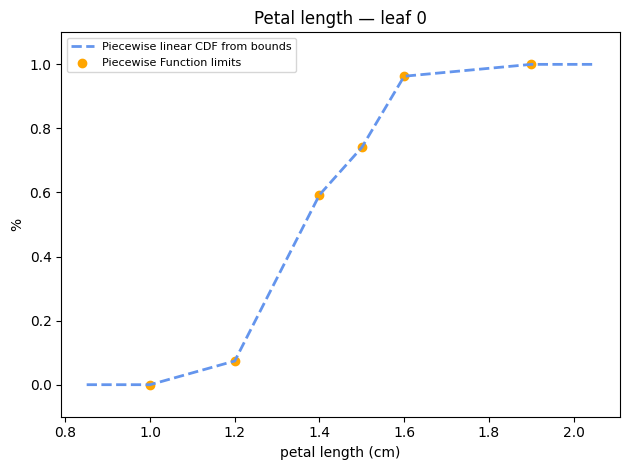

In [4]:
import matplotlib.pyplot as plt

# Pick the marginal distribution of petal length from the first leaf
first_leaf = list(model.leaves.values())[0]
numeric_dist = first_leaf.distributions[varnames['petal length (cm)']]

fig = numeric_dist.plot(
    engine='matplotlib',
    title='Petal length — leaf 0',
    xlabel='petal length (cm)',
    fname='petal_length_leaf0',
    directory=tmpdir,
)
plt.show()

### Symbolic distribution — bar chart

Symbolic variables are stored as multinomials.  We plot the species distribution from the same leaf.

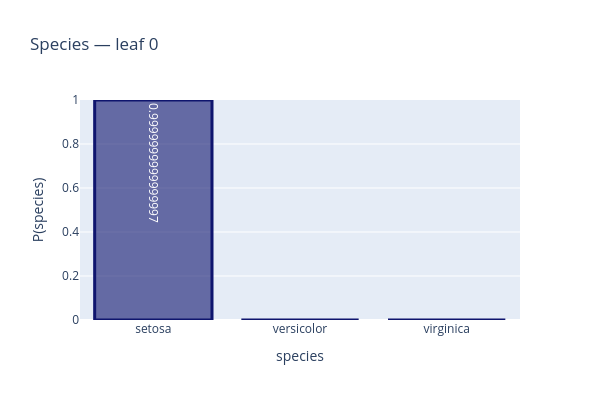

In [5]:
symbolic_dist = first_leaf.distributions[varnames['species']]

# The Matplotlib engine for multinomials saves to file;
# use Plotly to get an inline figure object
fig = symbolic_dist.plot(
    engine='plotly',
    title='Species — leaf 0',
)
fig.update_layout(height=400, width=600)
fig.show()

## Posterior Distributions

`JPT.posterior()` conditions the model on evidence and returns a distribution for each queried variable.  The distributions can be plotted with either engine.

### Numeric posterior — CDF

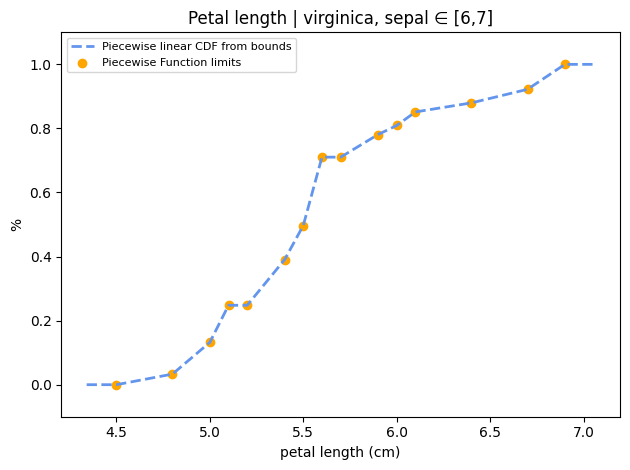

In [6]:
evidence = {
    'species': 'virginica',
    'sepal length (cm)': [6.0, 7.0],
}

post = model.posterior(
    variables=[
        varnames['petal length (cm)'],
        varnames['petal width (cm)'],
        varnames['species'],
    ],
    evidence=evidence,
)

fig = post[varnames['petal length (cm)']].plot(
    engine='matplotlib',
    title='Petal length | virginica, sepal ∈ [6,7]',
    xlabel='petal length (cm)',
    fname='petal_length_post',
    directory=tmpdir,
)
plt.show()

### Numeric posterior — PDF (manual plot)

The CDF plot is the native representation.  To visualise the PDF, evaluate it on a fine grid:

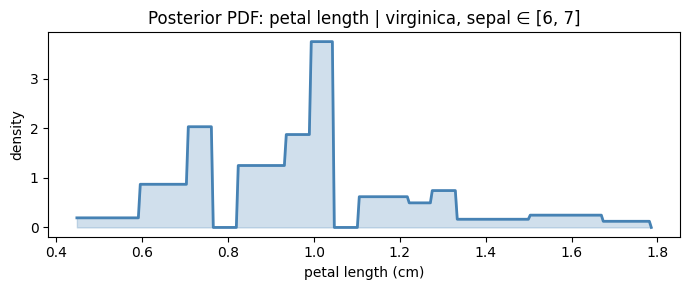

In [7]:
import numpy as np

dist = post[varnames['petal length (cm)']]
lo, hi = dist.ppf(0.005), dist.ppf(0.995)
xs = np.linspace(lo, hi, 300)
ys = [dist.pdf(x) for x in xs]

fig, ax = plt.subplots(figsize=(7, 3))
ax.fill_between(xs, ys, alpha=0.25, color='steelblue')
ax.plot(xs, ys, color='steelblue', linewidth=2)
ax.set_xlabel('petal length (cm)')
ax.set_ylabel('density')
ax.set_title('Posterior PDF: petal length | virginica, sepal ∈ [6, 7]')
fig.tight_layout()
plt.show()

### Symbolic posterior — bar chart (Plotly)

The Plotly engine returns an interactive figure directly, including hover tooltips with exact probabilities.

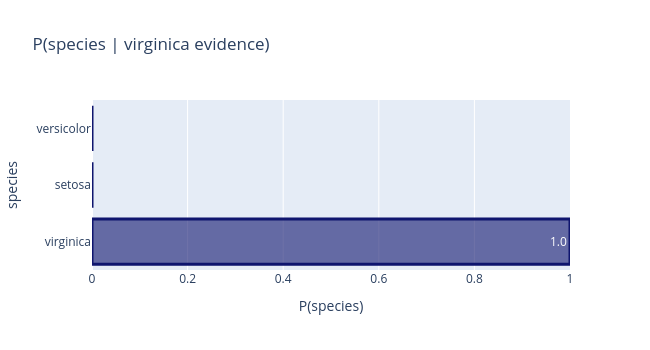

In [8]:
fig = post[varnames['species']].plot(
    engine='plotly',
    title='P(species | virginica evidence)',
    horizontal=True,
)
fig.update_layout(height=350, width=650)
fig.show()

## Plotly Engine — Numeric CDF

The Plotly numeric plot shows the piecewise-linear CDF with knot points highlighted and full zoom/pan support.

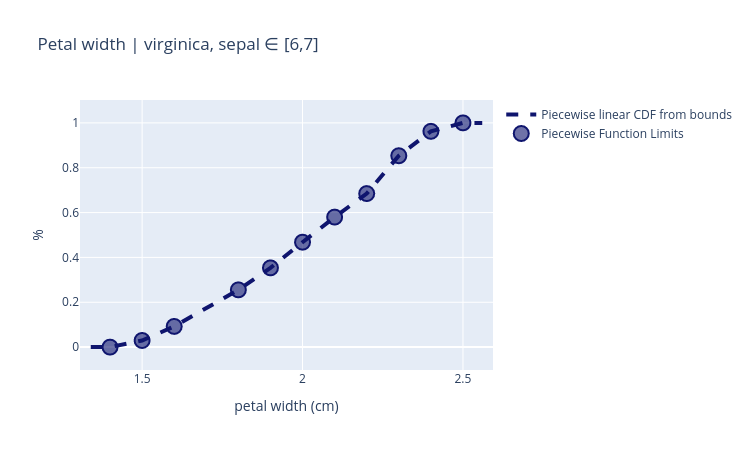

In [9]:
fig = post[varnames['petal width (cm)']].plot(
    engine='plotly',
    title='Petal width | virginica, sepal ∈ [6,7]',
    xlabel='petal width (cm)',
)
fig.update_layout(height=450, width=750)
fig.show()

## Customising Colours

All plot methods accept a `color` parameter (Plotly) or use Matplotlib's style system.  For the tree, `nodefill` and `leaffill` control node background colours.

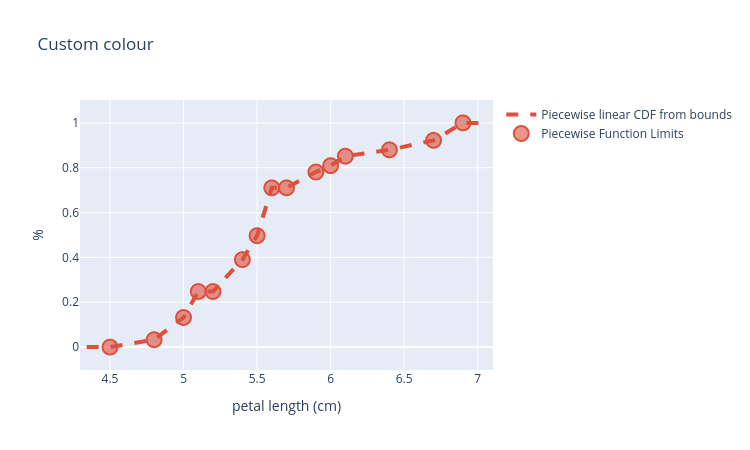

In [10]:
# Plotly: custom RGB colour
fig = post[varnames['petal length (cm)']].plot(
    engine='plotly',
    title='Custom colour',
    xlabel='petal length (cm)',
    color='rgb(220, 80, 60)',
)
fig.update_layout(height=450, width=750)
fig.show()

In [ ]:
# Tree with custom node colours
svg_path3 = model.plot(
    title='Iris JPT — custom colours',
    filename='iris_coloured',
    directory=tmpdir,
    engine='matplotlib',
    nodefill='#d0e8ff',
    leaffill='#ffe8d0',
    view=False,
)
display(SVG(svg_path3))

## Saving Figures

### Static images (Matplotlib)

Pass `fname` and `directory` to any distribution `.plot()` call — the file is written automatically.

```python
dist.plot(
    engine='matplotlib',
    fname='petal_length.png',
    directory='/tmp',
)
```

### Interactive HTML (Plotly)

Pass an `.html` filename to get a self-contained interactive page:

```python
fig = dist.plot(engine='plotly', fname='petal_length.html', directory='/tmp')
```

### Static images (Plotly + kaleido)

Use any other extension (`.png`, `.svg`, `.jpeg`, `.webp`):

```python
fig = dist.plot(engine='plotly', fname='petal_length.svg', directory='/tmp')
# or call kaleido directly on the returned figure:
fig.write_image('/tmp/petal_length.png', scale=2)
```